In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [3]:
df = pd.read_csv("/kaggle/input/datasets/zxcdfg/solarload/EE467_EDA_Data_Group15_Solar.csv")
df["Timestamp"] = pd.to_datetime(df["Timestamp"], utc=True, errors="coerce")
df = df.dropna()
df = df.sort_values("Timestamp")

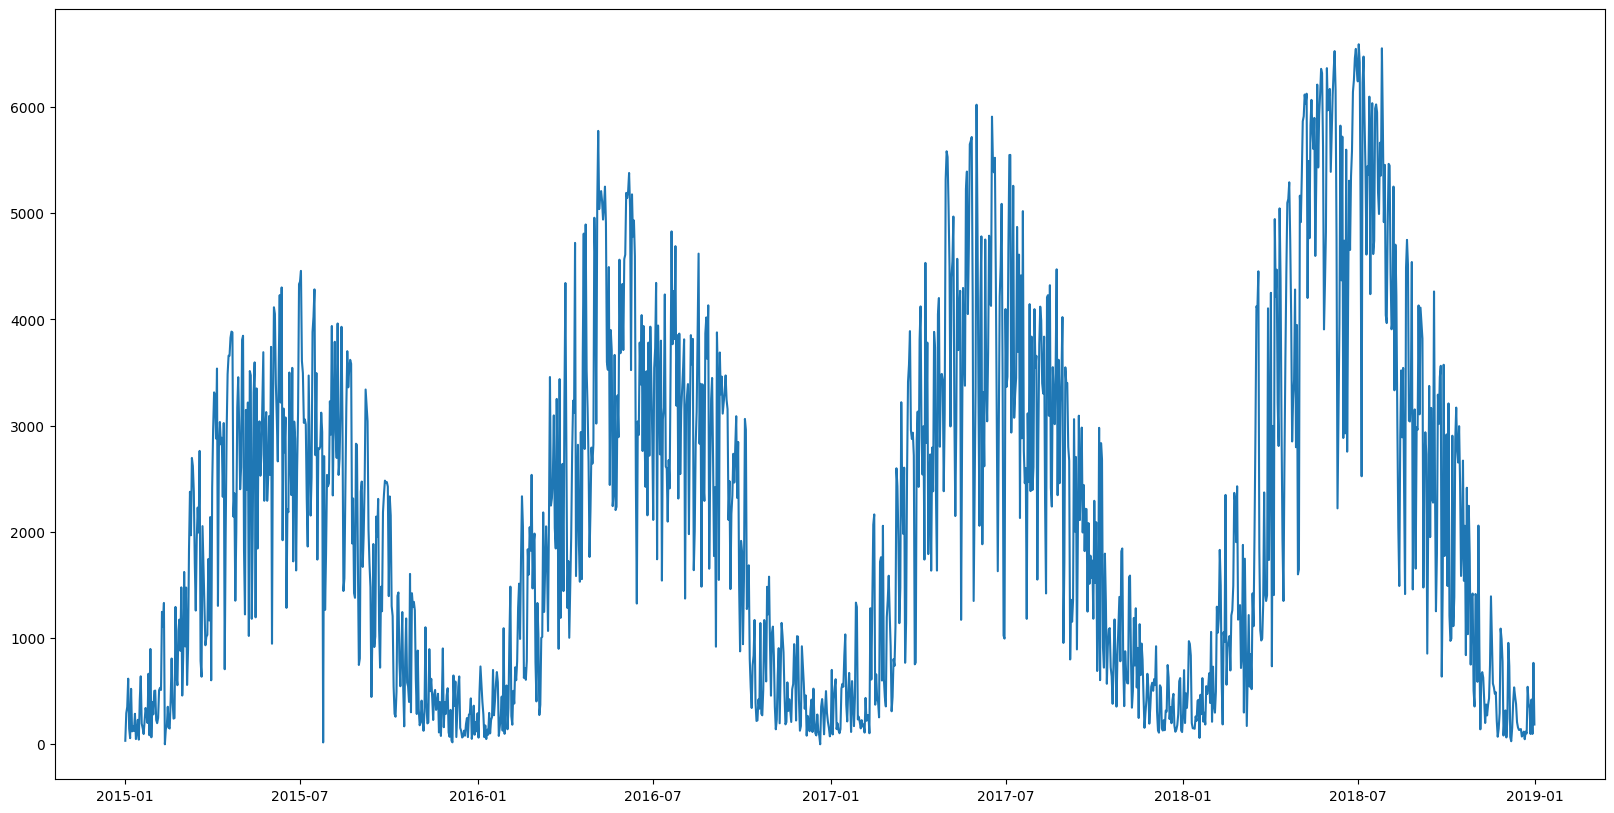

In [7]:
day = df.groupby(df["Timestamp"].dt.date)["Value (MW)"].sum()
plt.figure(figsize=(20, 10))
plt.plot(day.index, day.values)
plt.show()

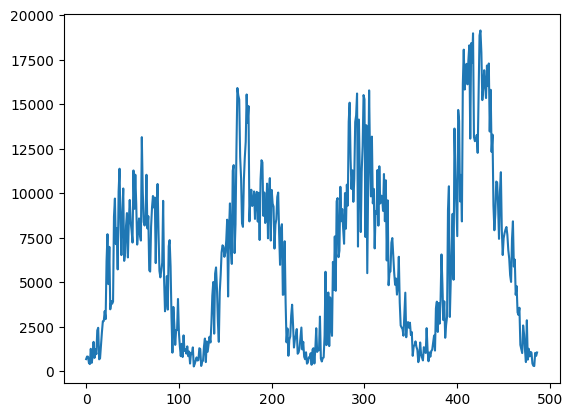

In [8]:
df_day = day.reset_index(drop=True)
df_2day = df_day.groupby(df_day.index // 3).sum()
df_2day = pd.DataFrame(df_2day)
plt.plot(df_2day.index, df_2day["Value (MW)"].values)
plt.show()

/tmp/ipykernel_55/4098223475.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  week = df.groupby(df["Timestamp"].dt.to_period("W"))["Value (MW)"].sum()


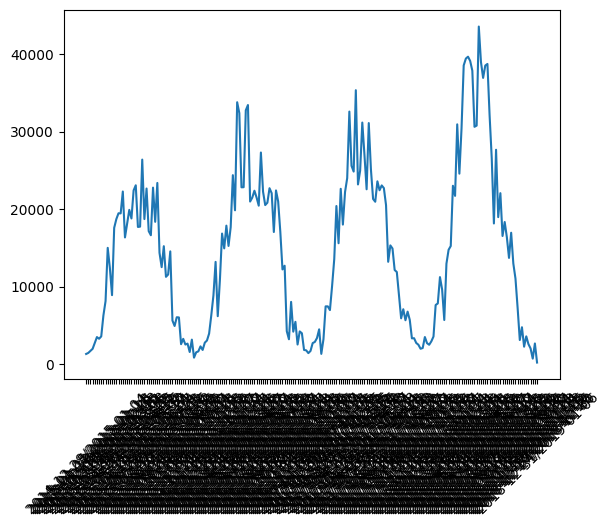

In [9]:
week = df.groupby(df["Timestamp"].dt.to_period("W"))["Value (MW)"].sum()
plt.plot(week.index.astype(str), week.values)
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_55/3423350954.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  month = df.groupby(df["Timestamp"].dt.to_period("M"))["Value (MW)"].sum()


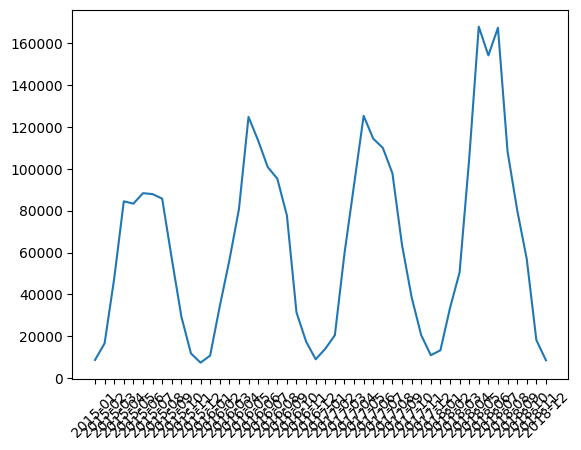

In [10]:
month = df.groupby(df["Timestamp"].dt.to_period("M"))["Value (MW)"].sum()
plt.plot(month.index.astype(str), month.values)
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_55/4075135345.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  year = df.groupby(df["Timestamp"].dt.to_period("Y"))["Value (MW)"].sum()


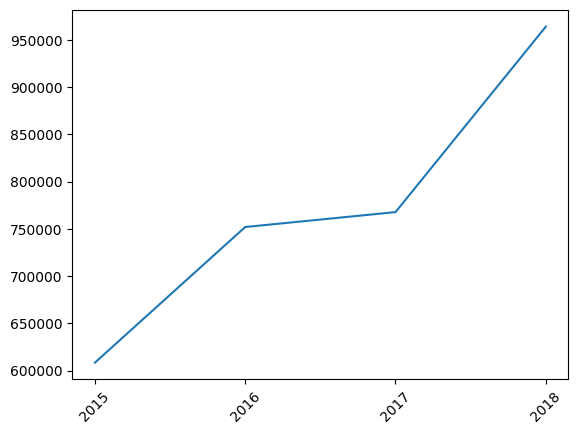

In [11]:
year = df.groupby(df["Timestamp"].dt.to_period("Y"))["Value (MW)"].sum()
plt.plot(year.index.astype(str), year.values)
plt.xticks(rotation=45)
plt.show()

In [12]:
result_0 = adfuller(df_2day["Value (MW)"].values)
print(result_0[0], result_0[1])

-3.949394293530026 0.0016999543831719122


In [14]:
df_2day["value_dif"] = df_2day["Value (MW)"].diff()
df_2day = df_2day.dropna()

In [15]:
result_1 = adfuller(df_2day["value_dif"])
print(result_1[0], result_1[1])

-3.0153138374499635 0.03348881897444665


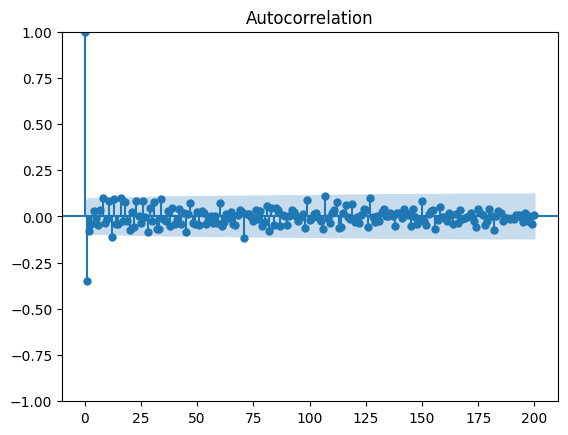

In [16]:
plot_acf(df_2day["value_dif"], lags=200)
plt.show()

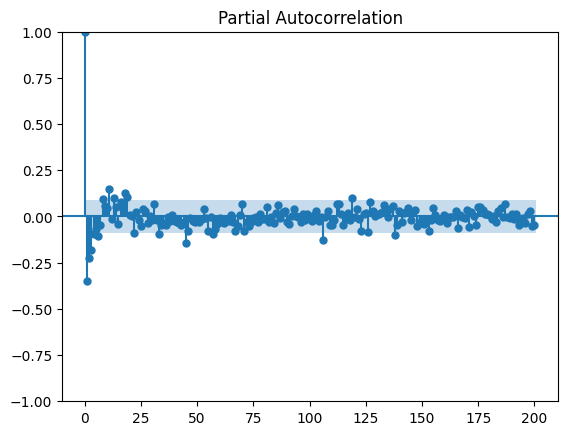

In [17]:
plot_pacf(df_2day["value_dif"], lags=200)
plt.show()

In [18]:
train_size = int(len(df_2day["Value (MW)"]) * 0.8)
train = df_2day["Value (MW)"][:train_size]
test = df_2day["Value (MW)"][train_size:]

In [19]:
model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,0,122))
result = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [20]:
forecast = result.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


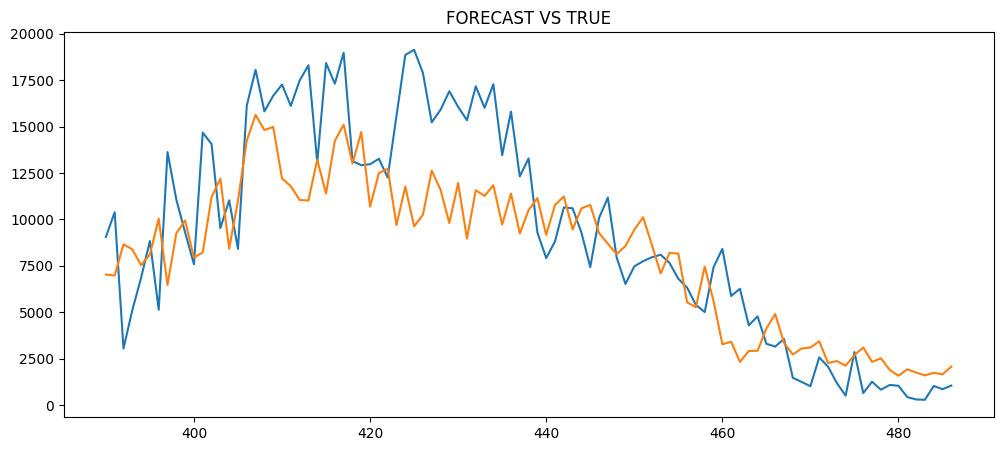

In [23]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test.values)
plt.plot(test.index, forecast.values)
plt.title('FORECAST VS TRUE')
plt.show()

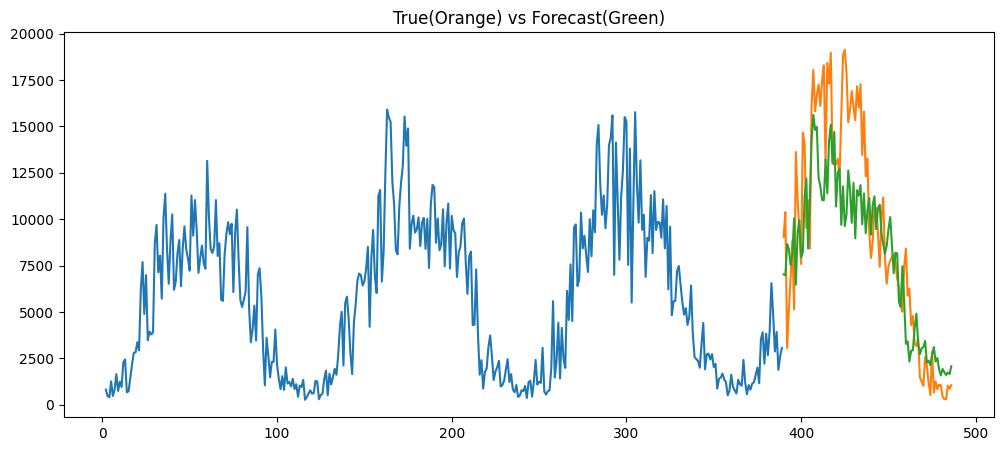

In [25]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train.values)
plt.plot(test.index, test.values)
plt.plot(test.index, forecast.values)
plt.title('True(Orange) vs Forecast(Green)')
plt.show()

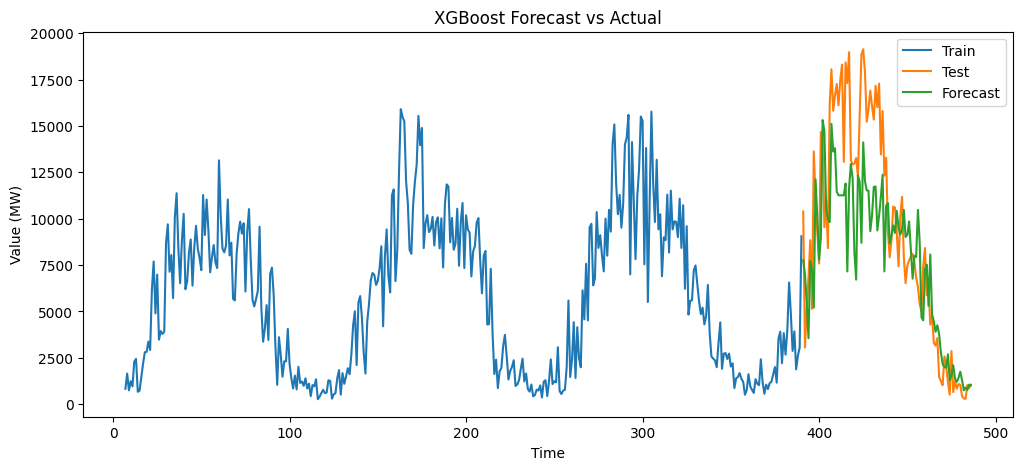

In [31]:
from xgboost import XGBRegressor

df_ml = df_2day.copy()
df_ml["lag1"] = df_ml["Value (MW)"].shift(1)
df_ml["lag2"] = df_ml["Value (MW)"].shift(2)
df_ml["lag3"] = df_ml["Value (MW)"].shift(3)
df_ml["lag4"] = df_ml["Value (MW)"].shift(4)
df_ml["lag5"] = df_ml["Value (MW)"].shift(5)
df_ml = df_ml.dropna()

train_size = int(len(df_ml) * 0.8)
train_ml = df_ml.iloc[:train_size]
test_ml = df_ml.iloc[train_size:]

X_train_ml = train_ml.drop(columns=["Value (MW)", "value_dif"])
y_train_ml = train_ml["Value (MW)"]

X_test_ml = test_ml.drop(columns=["Value (MW)", "value_dif"])
y_test_ml = test_ml["Value (MW)"]

model_xgb = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05)
model_xgb.fit(X_train_ml, y_train_ml)

y_pred_xgb = model_xgb.predict(X_test_ml)

plt.figure(figsize=(12,5))
plt.plot(train_ml.index, y_train_ml.values, label="Train")
plt.plot(test_ml.index, y_test_ml.values, label="Test")
plt.plot(test_ml.index, y_pred_xgb, label="Forecast")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Value (MW)")
plt.title("XGBoost Forecast vs Actual")
plt.show()

In [32]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_sarima = np.sqrt(mean_squared_error(test.values, forecast.values))
rmse_xgb = np.sqrt(mean_squared_error(y_test_ml.values, y_pred_xgb))

rmse_sarima, rmse_xgb

(np.float64(3356.1368418528423), np.float64(3617.934188143295))